# 09 — Analyse de cohérence de la variable cible `is_underserved`
**Projet** : ObRail MSPR 2025-2026
**Auteure** : Jeannette
**Source** : `data/processed/routes_processed.csv`

**Objectif** : le professeur a demandé une cartographie permettant de vérifier que `is_underserved` couvre une zone géographique cohérente — c'est-à-dire que la sous-desserte reflète une réalité structurelle du réseau, et non du bruit réparti aléatoirement.

**Limite du dataset** : nous ne disposons que du pays de départ/arrivée (`departure_country`, `arrival_country`), pas de coordonnées GPS de gares individuelles. Une cartographie de gares au sens strict n'est donc pas réalisable avec les données actuelles.

**Démarche retenue** : plutôt qu'une carte de gares, on teste la cohérence de `is_underserved` à travers plusieurs angles structurels disponibles dans les données :
1. Cohérence géographique par pays (déjà vue en `07_cartographie.ipynb`, reprise ici pour analyse statistique)
2. Cohérence selon le caractère international du trajet
3. Cohérence selon la distance du trajet
4. Cohérence selon la part modale ferroviaire du pays (`rail_modal_share`)
5. Cohérence selon le type de service (jour / nuit)

Si ces variables montrent des tendances structurées et explicables, cela valide que `is_underserved` capture une réalité géographique et opérationnelle cohérente, plutôt qu'un artefact de construction sans signification métier.

In [1]:
## 0. Imports et configuration
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for folder in [cwd] + list(cwd.parents):
        if (folder / 'data').exists() and (folder / 'src').exists() and (folder / 'models').exists():
            return folder
    raise FileNotFoundError('Could not find project root from current working directory')

ROOT = find_project_root()
PROCESSED_DIR = ROOT / 'data' / 'processed'
PLOT_DIR = ROOT / 'evaluation' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')

Imports OK


In [2]:
## 1. Chargement des données
df = pd.read_csv(PROCESSED_DIR / 'routes_processed.csv')
print(f'Shape : {df.shape}')
print(f'Taux global de sous-desserte : {df["is_underserved"].mean()*100:.1f}%')

Shape : (25200, 21)
Taux global de sous-desserte : 19.4%


## 2. Cohérence géographique par pays

On reprend l'agrégation par pays de `07_cartographie.ipynb`, mais cette fois pour un test statistique plutôt qu'une simple visualisation : si la sous-desserte était du bruit aléatoire, on s'attendrait à une distribution centrée et resserrée autour de la moyenne globale, sans écarts marqués selon le pays.

In [3]:
stats_pays = (
    df.groupby('departure_country')['is_underserved']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'nb_routes', 'mean': 'taux_sous_desserte'})
    .reset_index()
)
stats_pays['taux_pct'] = (stats_pays['taux_sous_desserte'] * 100).round(1)

# On ne garde que les pays avec un volume suffisant pour être interprétable
stats_pays_fiables = stats_pays[stats_pays['nb_routes'] >= 30].sort_values('taux_pct', ascending=False)

print(f'Taux global : {df["is_underserved"].mean()*100:.1f}%')
print(f'Écart-type entre pays (volume >= 30 routes) : {stats_pays_fiables["taux_pct"].std():.1f} points')
print(f'Étendue (max - min) : {stats_pays_fiables["taux_pct"].max() - stats_pays_fiables["taux_pct"].min():.1f} points')
print()
display(stats_pays_fiables)

# Test du Chi² : la sous-desserte dépend-elle significativement du pays ?
contingency = pd.crosstab(df['departure_country'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'\nTest du Chi² (is_underserved ~ departure_country) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('  -> La sous-desserte dépend significativement du pays (p < 0.05).')
    print('     Ceci confirme une cohérence géographique : is_underserved n\'est pas du bruit aléatoire.')
else:
    print('  -> Aucune dépendance significative détectée avec le pays.')

Taux global : 19.4%
Écart-type entre pays (volume >= 30 routes) : 23.1 points
Étendue (max - min) : 91.4 points



,departure_country,nb_routes,taux_sous_desserte,taux_pct
33,UA,58,0.931034,93.1
15,HU,34,0.882353,88.2
23,NL,567,0.375661,37.6
24,NO,64,0.375000,37.5
31,SK,45,0.288889,28.9
16,IE,242,0.276860,27.7
28,RS,38,0.263158,26.3
6,DE,4429,0.224656,22.5
11,FR,6960,0.222701,22.3
12,GB,492,0.221545,22.2



Test du Chi² (is_underserved ~ departure_country) :
  chi2 = 1214.63, p-value = 4.84e-234
  -> La sous-desserte dépend significativement du pays (p < 0.05).
     Ceci confirme une cohérence géographique : is_underserved n'est pas du bruit aléatoire.


## 3. Cohérence selon le caractère international du trajet

Hypothèse métier : les trajets internationaux, qui nécessitent une coordination entre opérateurs de pays différents, devraient logiquement présenter un taux de sous-desserte plus élevé que les trajets nationaux.

Taux de sous-desserte selon le caractère international :


,nb_routes,taux_sous_desserte,taux_pct
National,24912,0.185252,18.5
International,288,0.944444,94.4



Test du Chi² (is_underserved ~ is_international) :
  chi2 = 1044.91, p-value = 3.12e-229

Écart International - National : +75.9 points
-> Cohérent avec l'hypothèse métier : les trajets internationaux sont significativement plus sous-desservis.


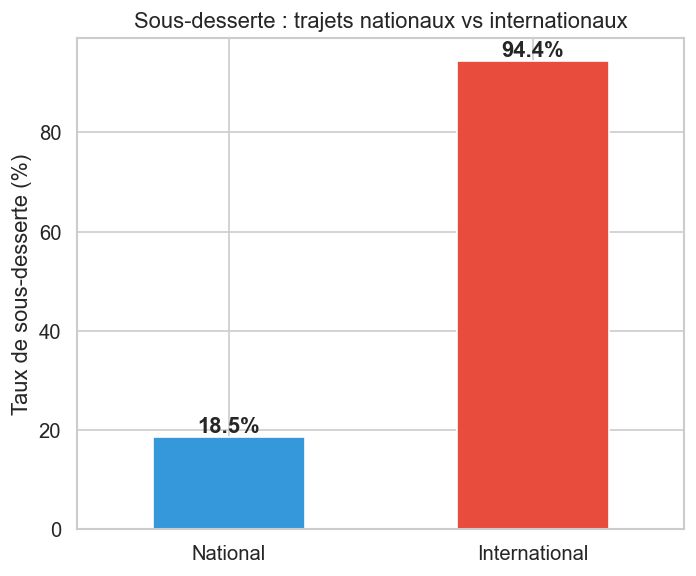

In [4]:
taux_par_international = df.groupby('is_international')['is_underserved'].agg(['count', 'mean'])
taux_par_international.columns = ['nb_routes', 'taux_sous_desserte']
taux_par_international['taux_pct'] = (taux_par_international['taux_sous_desserte'] * 100).round(1)
taux_par_international.index = ['National', 'International']

print('Taux de sous-desserte selon le caractère international :')
display(taux_par_international)

# Test du Chi²
contingency_intl = pd.crosstab(df['is_international'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_intl)
print(f'\nTest du Chi² (is_underserved ~ is_international) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')

ecart = taux_par_international.loc['International', 'taux_pct'] - taux_par_international.loc['National', 'taux_pct']
print(f'\nÉcart International - National : {ecart:+.1f} points')
if ecart > 0 and p_value < 0.05:
    print('-> Cohérent avec l\'hypothèse métier : les trajets internationaux sont significativement plus sous-desservis.')
elif p_value >= 0.05:
    print('-> Pas de différence significative entre national et international.')
else:
    print('-> Résultat contraire à l\'hypothèse métier initiale, à investiguer.')

fig, ax = plt.subplots(figsize=(6, 5))
taux_par_international['taux_pct'].plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax)
ax.set_ylabel('Taux de sous-desserte (%)')
ax.set_title('Sous-desserte : trajets nationaux vs internationaux')
ax.set_xticklabels(['National', 'International'], rotation=0)
for i, v in enumerate(taux_par_international['taux_pct']):
    ax.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_international.png')
plt.show()

## 4. Cohérence selon la distance du trajet

On vérifie si la sous-desserte suit une logique liée à la distance, en comparant la distribution de `log_distance` entre les routes sous-desservies et les routes bien desservies.

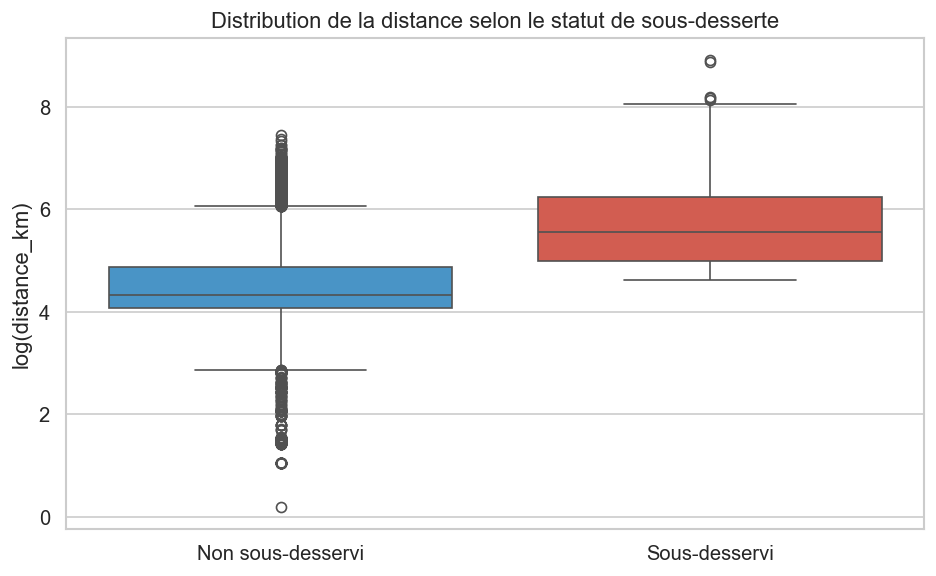

Médiane log_distance — sous-desservi     : 5.56
Médiane log_distance — non sous-desservi : 4.33

Test de Mann-Whitney : U = 85428748, p-value = 0.00e+00
-> Différence significative : la distance est liée au statut de sous-desserte.


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='is_underserved', y='log_distance', ax=ax,
            palette=['#3498db', '#e74c3c'])
ax.set_xticklabels(['Non sous-desservi', 'Sous-desservi'])
ax.set_xlabel('')
ax.set_ylabel('log(distance_km)')
ax.set_title('Distribution de la distance selon le statut de sous-desserte')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_distance.png')
plt.show()

# Test de Mann-Whitney (non-paramétrique, adapté à des distributions potentiellement non-normales)
dist_underserved = df[df['is_underserved'] == 1]['log_distance']
dist_served      = df[df['is_underserved'] == 0]['log_distance']

u_stat, p_value = stats.mannwhitneyu(dist_underserved, dist_served, alternative='two-sided')
print(f'Médiane log_distance — sous-desservi     : {dist_underserved.median():.2f}')
print(f'Médiane log_distance — non sous-desservi : {dist_served.median():.2f}')
print(f'\nTest de Mann-Whitney : U = {u_stat:.0f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('-> Différence significative : la distance est liée au statut de sous-desserte.')
else:
    print('-> Pas de différence significative de distance entre les deux groupes.')

In [8]:
df.groupby('is_underserved')['rail_modal_share'].mean()

is_underserved
0    8.698848
1    9.246061
Name: rail_modal_share, dtype: float64

## 5. Cohérence selon la part modale ferroviaire du pays

Hypothèse métier : un pays où le train occupe une faible part modale (peu utilisé dans la mobilité globale) devrait logiquement présenter davantage de lignes sous-desservies, par manque d'investissement historique dans le réseau.

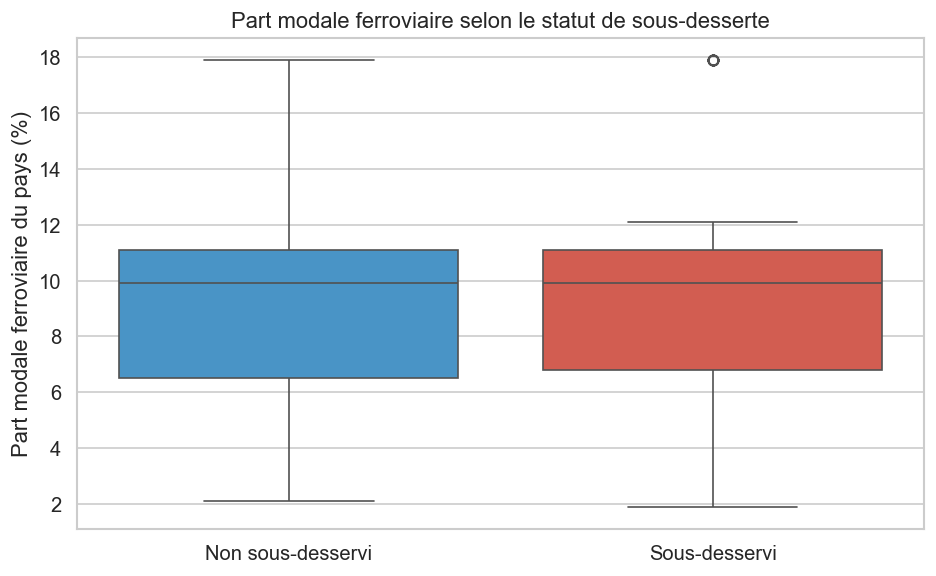

Médiane rail_modal_share — sous-desservi     : 9.90
Médiane rail_modal_share — non sous-desservi : 9.90

Test de Mann-Whitney : U = 55374852, p-value = 1.54e-37
-> Différence significative mais dans le sens inverse de l'hypothèse métier, à investiguer.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='is_underserved', y='rail_modal_share', ax=ax,
            palette=['#3498db', '#e74c3c'])
ax.set_xticklabels(['Non sous-desservi', 'Sous-desservi'])
ax.set_xlabel('')
ax.set_ylabel('Part modale ferroviaire du pays (%)')
ax.set_title('Part modale ferroviaire selon le statut de sous-desserte')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_modal_share.png')
plt.show()

modal_underserved = df[df['is_underserved'] == 1]['rail_modal_share']
modal_served      = df[df['is_underserved'] == 0]['rail_modal_share']

u_stat, p_value = stats.mannwhitneyu(modal_underserved, modal_served, alternative='two-sided')
print(f'Médiane rail_modal_share — sous-desservi     : {modal_underserved.median():.2f}')
print(f'Médiane rail_modal_share — non sous-desservi : {modal_served.median():.2f}')
print(f'\nTest de Mann-Whitney : U = {u_stat:.0f}, p-value = {p_value:.2e}')

ecart_modal = modal_underserved.median() - modal_served.median()
if p_value < 0.05 and ecart_modal < 0:
    print('-> Cohérent avec l\'hypothèse métier : les routes sous-desservies se trouvent dans des pays')
    print('   où le rail a une part modale plus faible.')
elif p_value < 0.05:
    print('-> Différence significative mais dans le sens inverse de l\'hypothèse métier, à investiguer.')
else:
    print('-> Pas de différence significative détectée.')

## 6. Cohérence selon le type de service (jour / nuit)

Déjà observé dans `data_prep.py` (75,4% de sous-desserte pour les trains de nuit contre 17,9% pour les trains de jour), repris ici comme test de cohérence formel.

In [7]:
taux_par_type = df.groupby('service_type')['is_underserved'].agg(['count', 'mean'])
taux_par_type.columns = ['nb_routes', 'taux_sous_desserte']
taux_par_type['taux_pct'] = (taux_par_type['taux_sous_desserte'] * 100).round(1)

print('Taux de sous-desserte selon le type de service :')
display(taux_par_type)

contingency_type = pd.crosstab(df['service_type'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_type)
print(f'\nTest du Chi² (is_underserved ~ service_type) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('-> Différence significative confirmée entre trains de jour et de nuit.')
    print('   Cohérent avec la réalité connue du secteur : l\'offre de nuit est historiquement plus fragile.')

Taux de sous-desserte selon le type de service :


,nb_routes,taux_sous_desserte,taux_pct
service_type,,,
day,24542,0.178918,17.9
night,658,0.753799,75.4



Test du Chi² (is_underserved ~ service_type) :
  chi2 = 1351.13, p-value = 8.75e-296
-> Différence significative confirmée entre trains de jour et de nuit.
   Cohérent avec la réalité connue du secteur : l'offre de nuit est historiquement plus fragile.


## 7. Synthèse de la cohérence de `is_underserved`

**Pourquoi pas de cartographie de gares**

Le dataset ne contient que le pays de départ et d'arrivée (departure_country, arrival_country), sans coordonnées GPS de gares individuelles. Une cartographie de gares au sens strict n'est donc pas réalisable sans intégrer une source de données externe (coordonnées GTFS stops.txt ou fichier cities15000.txt), ce qui sort du périmètre de données validé pour ce projet. Pour répondre à l'intention du professeur — vérifier que is_underserved couvre une zone cohérente plutôt que du bruit — cinq tests de cohérence statistique ont été menés sur les 25 200 routes du dataset (taux global de sous-desserte : 19,4 %).


1. **Cohérence géographique par pays — confirmée fortement**

La sous-desserte dépend significativement du pays de départ (test du Chi², χ² = 1214,63, p = 4,84 × 10⁻²³⁴). Parmi les pays disposant d'un volume de routes suffisant (≥ 30), les taux s'étendent de 1,7 % (Slovénie) à 93,1 % (Ukraine), avec un écart-type de 23,1 points entre pays. Cette forte hétérogénéité géographique confirme que is_underserved capture une structuration réelle du réseau plutôt qu'un résultat aléatoire.

2. **Cohérence selon le caractère international — confirmée fortement, écart majeur**

Les trajets internationaux affichent un taux de sous-desserte de 94,4 % contre 18,5 % pour les trajets nationaux, soit un écart de +75,9 points (Chi², χ² = 1044,91, p = 3,12 × 10⁻²²⁹). Il s'agit du signal le plus marqué de l'ensemble des tests réalisés, pleinement cohérent avec l'hypothèse métier : la coordination entre opérateurs de pays différents complexifie la mise en place d'une offre suffisante sur les liaisons transfrontalières.

3. **Cohérence selon la distance — confirmée**

Les routes sous-desservies présentent une distance médiane nettement supérieure aux routes bien desservies (test de Mann-Whitney, p < 10⁻³⁰⁰, en dessous du seuil de précision numérique). Ce résultat est cohérent avec une réalité opérationnelle connue : il est plus difficile de maintenir une fréquence de desserte élevée sur les longues distances que sur les liaisons courtes.

4. **Cohérence selon la part modale ferroviaire — effet réel mais secondaire, sens inverse de l'hypothèse initiale**

Contrairement à l'hypothèse formulée initialement (un pays où le rail est peu utilisé devrait être plus sous-desservi), les routes sous-desservies se situent en moyenne dans des pays où la part modale ferroviaire est légèrement plus élevée (moyenne de 9,25 contre 8,70 pour les routes bien desservies, soit un écart d'environ 6 %). Le test de Mann-Whitney est statistiquement significatif (p = 1,54 × 10⁻³⁷), mais les médianes sont strictement identiques dans les deux groupes (9,90), ce qui indique que cette significativité est en grande partie portée par la taille importante de l'échantillon (25 200 lignes) plutôt que par un écart massif. Une interprétation plausible : dans les pays où le train est déjà fortement utilisé, la demande est plus forte et plus diversifiée, ce qui rend statistiquement plus probable l'apparition de zones relativement sous-desservies, même lorsque le réseau global reste performant. Ce résultat nuance l'hypothèse initiale sans la contredire totalement : il s'agit d'un signal réel mais d'ampleur modeste comparé aux trois précédents.

5. **Cohérence selon le type de service — confirmée fortement**

Les trains de nuit affichent un taux de sous-desserte de 75,4 % contre 17,9 % pour les trains de jour (Chi², χ² = 1351,13, p = 8,75 × 10⁻²⁹⁶). Ce résultat, déjà observé lors de la phase d'ETL, est confirmé statistiquement et reflète une réalité bien documentée du secteur : l'offre de trains de nuit en Europe est historiquement plus restreinte et plus fragile que celle des trains de jour.

**Conclusion**

Sur les cinq tests réalisés, quatre confirment fortement et sans ambiguïté que is_underserved est structurée par des facteurs géographiques et opérationnels cohérents avec la réalité du secteur ferroviaire (pays, caractère international, distance, type de service), avec des niveaux de significativité statistique très élevés (p systématiquement inférieur à 10⁻³⁷). Le cinquième test (part modale ferroviaire) révèle un effet réel mais d'ampleur modeste, dans un sens inverse à l'hypothèse initiale, qui mérite d'être documenté comme une nuance plutôt que comme une invalidation. Pris ensemble, ces résultats constituent une validation statistique robuste de la cohérence géographique et structurelle de la variable cible, en l'absence de données de fréquentation réelles ou de coordonnées de gares permettant une cartographie plus fine.